# Rush Impact

Compares weekday rush-window performance against non-rush periods.

In [1]:
from pathlib import Path
import importlib.util
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "analysis"))

spec = importlib.util.spec_from_file_location(
    "rush_impact",
    PROJECT_ROOT / "analysis" / "rush-impact.py",
)
rush_impact = importlib.util.module_from_spec(spec)
spec.loader.exec_module(rush_impact)

DB = PROJECT_ROOT / "data" / "foli.db"
TIMEZONE = "Europe/Helsinki"
RUSH_WINDOWS = ["07:00-09:00", "15:00-18:00"]
INCLUDE_WEEKENDS = False
MIN_OBSERVATIONS = 50
LIMIT = 10
QUALITY_MODE = "conservative"
BUCKET = "trip-stop"

In [2]:
class Args:
    db = DB
    timezone = TIMEZONE
    rush_window = RUSH_WINDOWS
    include_weekends = INCLUDE_WEEKENDS
    min_observations = MIN_OBSERVATIONS
    limit = LIMIT
    quality_mode = QUALITY_MODE
    exclude_stop_call_disagreement = False
    bucket = BUCKET

df = rush_impact.load_observations(Args)
impact = rush_impact.build_rush_impact(Args, df)
impact

,line_ref,line_name,bucket_count_non_rush,bucket_count_rush,raw_poll_count_non_rush,raw_poll_count_rush,median_delay_min_non_rush,median_delay_min_rush,rush_median_delay_lift_min,p90_delay_min_non_rush,p90_delay_min_rush,rush_p90_delay_lift_min,pct_over_5_min_late_non_rush,pct_over_5_min_late_rush,rush_over_5_min_late_pct_point_lift
38,612,612,83,197,176,447,3.12,8.56,5.44,5.01,17.53,12.51,12.05,66.50,54.45
40,615,615,326,356,593,695,-1.17,6.35,7.52,4.05,15.40,11.35,6.13,55.90,49.76
86,N8,N8,100,96,613,560,-1.51,0.99,2.50,1.92,8.48,6.56,3.00,12.50,9.50
66,903,903,144,92,640,240,-1.07,0.00,1.07,2.61,7.60,4.99,4.86,22.83,17.96
61,79,79,150,84,329,233,-1.14,0.00,1.14,0.00,4.77,4.77,0.00,5.95,5.95
47,705,705,3681,696,8047,1459,0.00,1.41,1.41,3.58,7.92,4.34,7.44,24.71,17.27
60,77,77,149,195,407,260,-4.00,0.30,4.30,-1.00,3.28,4.28,0.67,1.54,0.87
31,51A,51A,602,235,1365,637,-0.73,-0.47,0.27,0.40,4.55,4.15,0.17,8.09,7.92
53,72,72,368,189,619,356,2.17,6.22,4.05,6.35,10.37,4.02,19.02,59.26,40.24
9,220,220,8850,1321,22138,3590,0.12,2.70,2.58,3.45,7.38,3.93,3.40,24.53,21.13


Text(0, 0.5, 'Line')

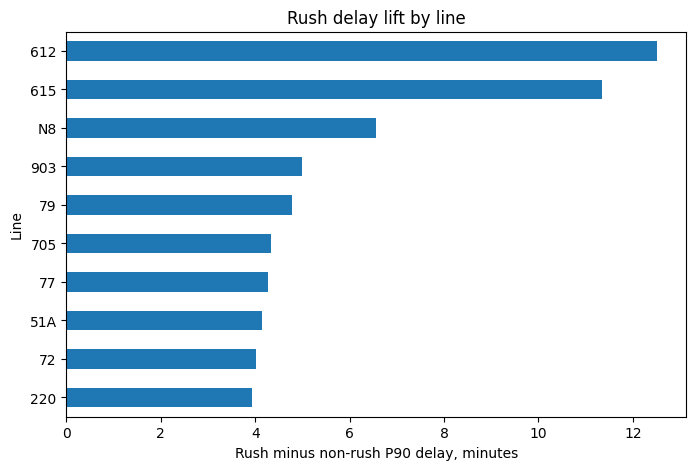

In [3]:
ax = impact.sort_values("rush_p90_delay_lift_min").plot.barh(
    x="line_ref",
    y="rush_p90_delay_lift_min",
    legend=False,
    figsize=(8, 5),
    title="Rush delay lift by line",
)
ax.set_xlabel("Rush minus non-rush P90 delay, minutes")
ax.set_ylabel("Line")